## Document Clustering project

In [29]:
# Import necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [30]:
# Step 1: Input text data
# Assume you have a list of documents as follows:
documents = [
    "Love encompasses a range of strong and positive emotional and mental states, from the most sublime virtue or good habit, the deepest interpersonal affection, to the simplest pleasure. An example of this range of meanings is that the love of a mother differs from the love of a spouse, which differs from the love for food. Most commonly, love refers to a feeling of strong attraction and emotional attachment",
    "People can have a profound dedication and immense appreciation for an object, principle, or objective, thereby experiencing a sense of love towards it. For example, compassionate outreach and volunteer workers love of their cause may sometimes be born not of interpersonal love but impersonal love, altruism, and strong spiritual or political convictions.People can also love material objects, animals, or activities if they invest themselves in bonding or otherwise identifying with those things. If sexual passion is also involved, then this feeling is called paraphilia.",
    "Although the nature or essence of love is a subject of frequent debate, different aspects of the word can be clarified by determining what is not love (antonyms of love). Love, as a general expression of positive sentiment (a stronger form of like), is commonly contrasted with hate (or neutral apathy). As a less sexual and more emotionally intimate form of romantic attachment, love is commonly contrasted with lust. As an interpersonal relationship with romantic overtones, love is sometimes contrasted with friendship, although the word love is often applied to close friendships or platonic love."
    "Friendship is a relationship of mutual affection between people.It is a stronger form of interpersonal bond than an acquaintance or an association, such as a classmate, neighbor, coworker, or colleague.In some cultures,the concept of friendship is restricted to a small number of very deep relationships in others, such as the U.S. and Canada, a person could have many friends, and perhaps a more intense relationship with one or two people, who may be called good friends or best friends. Other colloquial terms include besties or Best Friends Forever (BFFs). Although there are many forms of friendship, certain features are common to many such bonds, such as choosing to be with one another, enjoying time spent together, and being able to engage in a positive and supportive role to one another."]
    # Add more documents as needed

In [31]:
# Step 2: Represent each article as a vector
# Use TF-IDF vectorization for text data
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

In [32]:
# Step 3: Perform k-means clustering
k = 3  # Specify the number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

C:\Users\B N Rao\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=3, random_state=42)

In [33]:
# Add cluster labels to the original data
labels = kmeans.labels_
df = pd.DataFrame({'Document': documents, 'Cluster': labels})

In [34]:
# Step 4: Show data output (data visualization)
# Reduce dimensionality for visualization (using PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

Text(0, 0.5, 'y-axis')

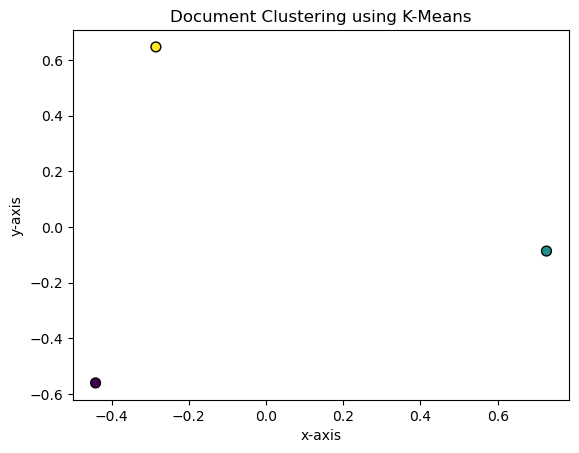

In [37]:
# Plot the clusters
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50)
plt.title('Document Clustering using K-Means')
plt.xlabel('x-axis')
plt.ylabel('y-axis')

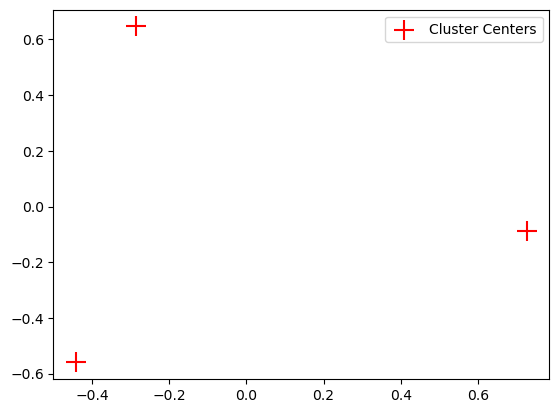

In [38]:
# Display cluster centers if needed
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='+', s=200, label='Cluster Centers')
plt.legend()
plt.show()